# Surface-code X-noise Monte Carlo with BP and BP+OSD-0

In this notebook, we study the threshold and runtime of native BP and BP+OSD+CS-0. We consider qubit planar/rotated surface code under uncorrelated **X-only** code-capacity noise.

It uses:
- `surface_code_X_stabilizers(d)` and `surface_code_Z_stabilizers(d)` to build the CSS checks,
- `bp_osd_cs_decode(...; osd_order=0)` as the BP+OSD decoder for the X-error sector,
- `bp_min_sum_decode()` as the native BP decoder for the X-error sector,
- a logical-success test based on whether the residual X error lies in the row space of the X stabilizers.

Conclusion:
- We find that the threshold is 9.2% for BP+OSD, consistent with the value obtained in Roffe's benchmark in https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.2.043423
- We find that there is no threshold for native BP, consistent with https://arxiv.org/pdf/2307.14989
- For relay BP, the threshold seems to be less than 7% (using IBM's parameter in https://arxiv.org/pdf/2506.01779)
- In terms of runtime, t(bare BP) < t(relay-BP) < t(BP-OSD-CS-0) as expected

In [22]:
using Plots
using Distributed
using LinearAlgebra
using JLD2

num_cores = length(Sys.cpu_info())
if nprocs() == 1
    addprocs(num_cores; exeflags=`--project=$(Base.active_project())`)
end

@everywhere begin
    using LatticeAlgorithms
    using LinearAlgebra
    using Dates
end

In [23]:
println("num_cores = $(num_cores)")

num_cores = 8


In [24]:
@everywhere function stabilizer_dict_to_check_matrix(dict::Dict{Int64, Vector{Int64}}, n::Int)
    H = zeros(Int64, length(dict), n)
    for (row_idx, qubits) in sort(collect(dict); by=first)
        H[row_idx, qubits] .= 1
    end
    return H
end

@everywhere function is_in_rowspace_mod2(v::AbstractVector{<:Integer}, H::AbstractMatrix{<:Integer})
    vrow = reshape(mod.(Int64.(v), 2), 1, :)
    return gf2_rank(H) == gf2_rank(vcat(mod.(Int64.(H), 2), vrow))
end

@everywhere function run_surface_xnoise_batch(
    HX::AbstractMatrix{<:Integer},
    HZ::AbstractMatrix{<:Integer},
    p::Float64,
    num_samples::Int;
    max_iter::Int=size(HZ, 2),
    λ::Int=60,
)
    n = size(HZ, 2)

    num_success = 0
    num_converged = 0
    decode_time = 0.0

    for _ in 1:num_samples
        x_error = Int64.(rand(n) .< p)
        sx = mod.(HZ * x_error, 2)

        local result
        decode_time += @elapsed result = bp_osd_cs_decode(
            HZ, sx, p;
            max_iter=max_iter,
            λ=λ,
            osd_order=0,
            check_to_bit_update_rule=:sum_product,
        )

        residual = mod.(x_error .+ result.error, 2)
        if is_in_rowspace_mod2(residual, HX)
            num_success += 1
        end

        if result.converged
            num_converged += 1
        end
    end

    return num_success, num_converged, decode_time
end

function get_grid_from_dict(dict::Dict, drange, prange)
    return [[dict[(Float64(p), Int(d))] for d in drange] for p in prange]
end


get_grid_from_dict (generic function with 1 method)

In [25]:
type_lattice = "surface_bp_osd0_xnoise"

num_samples = Int(1e5)
dmin, dmax = 3, 9
drange = dmin:2:dmax

prange = (7.0:0.25:11.0) / 100

max_iter_factor = 1
λ = 60

pd_range = [(Float64(p), Int(d)) for p in prange for d in drange]
println(pd_range)

num_samples_each_core = Int(ceil(num_samples / num_cores))
num_total_samples = num_samples_each_core * num_cores
println((num_samples_each_core=num_samples_each_core, num_samples=num_samples, num_total_samples=num_total_samples))



[(0.07, 3), (0.07, 5), (0.07, 7), (0.07, 9), (0.0725, 3), (0.0725, 5), (0.0725, 7), (0.0725, 9), (0.075, 3), (0.075, 5), (0.075, 7), (0.075, 9), (0.0775, 3), (0.0775, 5), (0.0775, 7), (0.0775, 9), (0.08, 3), (0.08, 5), (0.08, 7), (0.08, 9), (0.0825, 3), (0.0825, 5), (0.0825, 7), (0.0825, 9), (0.085, 3), (0.085, 5), (0.085, 7), (0.085, 9), (0.0875, 3), (0.0875, 5), (0.0875, 7), (0.0875, 9), (0.09, 3), (0.09, 5), (0.09, 7), (0.09, 9), (0.0925, 3), (0.0925, 5), (0.0925, 7), (0.0925, 9), (0.095, 3), (0.095, 5), (0.095, 7), (0.095, 9), (0.0975, 3), (0.0975, 5), (0.0975, 7), (0.0975, 9), (0.1, 3), (0.1, 5), (0.1, 7), (0.1, 9), (0.1025, 3), (0.1025, 5), (0.1025, 7), (0.1025, 9), (0.105, 3), (0.105, 5), (0.105, 7), (0.105, 9), (0.1075, 3), (0.1075, 5), (0.1075, 7), (0.1075, 9), (0.11, 3), (0.11, 5), (0.11, 7), (0.11, 9)]
(num_samples_each_core = 12500, num_samples = 100000, num_total_samples = 100000)


In [26]:
logfile = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples)_log.txt"
open(logfile, "w") do file
end

@time results = pmap(1:num_cores) do _
    p_success_list = Dict(pd_range .=> 0.0)
    p_converged_list = Dict(pd_range .=> 0.0)
    t_list = Dict(pd_range .=> 0.0)

    HXs = Dict{Int, Matrix{Int64}}()
    HZs = Dict{Int, Matrix{Int64}}()

    for d in drange
        HXs[d] = stabilizer_dict_to_check_matrix(surface_code_X_stabilizers(d), d^2)
        HZs[d] = stabilizer_dict_to_check_matrix(surface_code_Z_stabilizers(d), d^2)
    end

    for (ind_pd, (p, d)) in enumerate(pd_range)
        HX = HXs[d]
        HZ = HZs[d]
        max_iter = max_iter_factor * size(HZ, 2)

        walltime = @elapsed begin
            num_success, num_converged, decode_time = run_surface_xnoise_batch(
                HX, HZ, p, num_samples_each_core;
                max_iter=max_iter,
                λ=λ,
            )

            p_success_list[(p, d)] += num_success
            p_converged_list[(p, d)] += num_converged
            t_list[(p, d)] += decode_time
        end

        if myid() == 2
            println("$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))")
            open(logfile, "a") do file
                write(file, "$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))\n")
            end
        end
    end

    return p_success_list, p_converged_list, t_list
end

p_success_list = merge(+, [res[1] for res in results]...)
p_converged_list = merge(+, [res[2] for res in results]...)
t_list = merge(+, [res[3] for res in results]...)

for key in keys(p_success_list)
    p_success_list[key] /= num_total_samples
    p_converged_list[key] /= num_total_samples
    t_list[key] /= num_total_samples
end

fn = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples).jld2"
jldsave(
    fn;
    prange=prange,
    drange=drange,
    num_samples=num_total_samples,
    p_success_list=p_success_list,
    p_converged_list=p_converged_list,
    t_list=t_list,
    λ=λ,
    max_iter_factor=max_iter_factor,
)

      From worker 2:	1/68, d=3, p=0.07, walltime=0.967623166, 2026-03-29T13:56:22.729
      From worker 2:	2/68, d=5, p=0.07, walltime=2.925679709, 2026-03-29T13:56:25.700
      From worker 2:	3/68, d=7, p=0.07, walltime=16.600447625, 2026-03-29T13:56:42.304
      From worker 2:	4/68, d=9, p=0.07, walltime=34.570951875, 2026-03-29T13:57:16.881
      From worker 2:	5/68, d=3, p=0.0725, walltime=0.795091459, 2026-03-29T13:57:17.679
      From worker 2:	6/68, d=5, p=0.0725, walltime=3.846259291, 2026-03-29T13:57:21.529
      From worker 2:	7/68, d=7, p=0.0725, walltime=14.625553209, 2026-03-29T13:57:36.157
      From worker 2:	8/68, d=9, p=0.0725, walltime=36.511146209, 2026-03-29T13:58:12.672
      From worker 2:	9/68, d=3, p=0.075, walltime=0.669573083, 2026-03-29T13:58:13.351
      From worker 2:	10/68, d=5, p=0.075, walltime=3.233406584, 2026-03-29T13:58:16.587
      From worker 2:	11/68, d=7, p=0.075, walltime=12.796032125, 2026-03-29T13:58:29.385
      From worker 2:	12/68, d=9, p=0

In [27]:
p_success_grid = get_grid_from_dict(p_success_list, drange, prange)
p_converged_grid = get_grid_from_dict(p_converged_list, drange, prange)
t_grid = get_grid_from_dict(t_list, drange, prange)

17-element Vector{Vector{Float64}}:
 [4.017068223999999e-5, 0.00017183074289999986, 0.0009764803288000008, 0.0022678843728300008]
 [3.549577246000001e-5, 0.00023474298132000033, 0.0008528152040400002, 0.002412808957349999]
 [3.271644644e-5, 0.00020418258736999944, 0.0007760239695100003, 0.0023199924081899995]
 [3.3564440329999926e-5, 0.00018558414545999984, 0.0008084911132799995, 0.0023498104792300024]
 [3.0041533199999946e-5, 0.00019855592771999978, 0.0007935308574299997, 0.0024537334778600007]
 [3.0074016020000024e-5, 0.00019737649781999955, 0.0008037047348399993, 0.002333869382820003]
 [3.748481439000009e-5, 0.00018868906066000016, 0.0007953983920499985, 0.002328243992940002]
 [3.1568921190000054e-5, 0.00019590521472, 0.0008017747325399989, 0.0023041748710299964]
 [2.9869274910000022e-5, 0.00018442693904000034, 0.0008219719283999995, 0.00234432743612]
 [3.0130674080000014e-5, 0.00018811369209000041, 0.0008354526942199987, 0.002393351210419999]
 [2.979572365999997e-5, 0.0001874551116

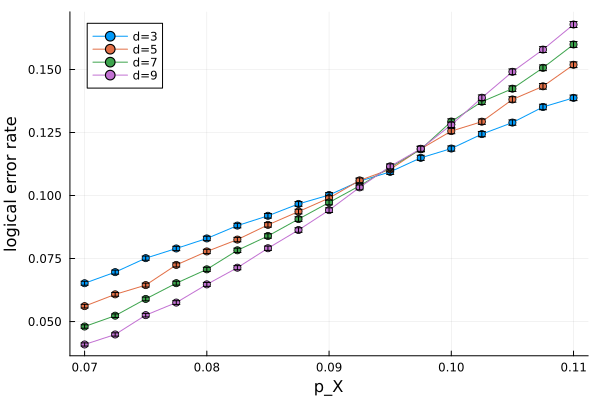

In [28]:
linecolors = get_color_palette(:auto, plot_color(:white))

g = plot()
for (ind_d, d) in enumerate(drange)
    p_success = [row[ind_d] for row in p_success_grid]
    p_fail = 1 .- p_success
    yerr = sqrt.(p_fail .* (1 .- p_fail) ./ num_total_samples)

    plot!(
        prange,
        p_fail;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
        yerr=yerr,
    )
end

plot!(
    xlabel="p_X",
    ylabel="logical error rate",
    # size=(900, 400),
)

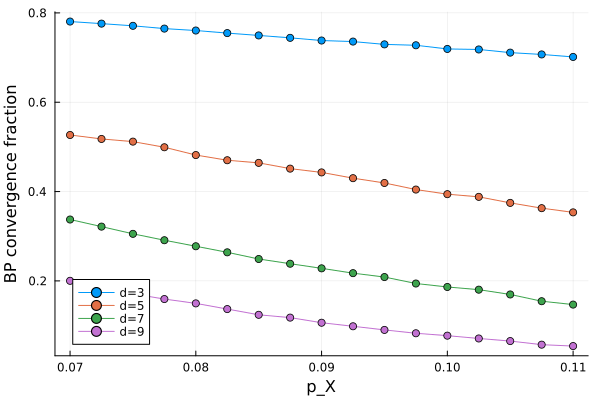

In [29]:
g2 = plot()
for (ind_d, d) in enumerate(drange)
    p_conv = [row[ind_d] for row in p_converged_grid]
    plot!(
        prange,
        p_conv;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="BP convergence fraction",
    # size=(900, 400),
)

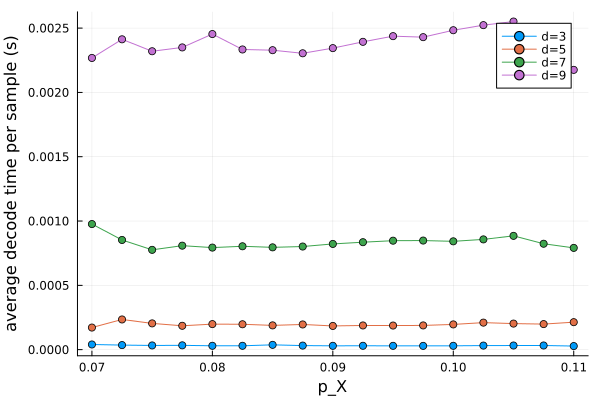

In [30]:
g3 = plot()
for (ind_d, d) in enumerate(drange)
    tavg = [row[ind_d] for row in t_grid]
    plot!(
        prange,
        tavg;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="average decode time per sample (s)",
    # size=(900, 400),
)

## Notes

- This notebook decodes **X-only** noise, so it uses the **Z-check matrix** as the input parity-check matrix to `bp_osd_cs_decode`.
- Success is declared when the residual X error lies in the row space of the X stabilizers, i.e. when it is a stabilizer and not a logical X operator.
- The decoder is run with `osd_order = 0`, so this notebook measures **BP+OSD-0**, not higher-order combination sweep.


# Benchmark with bare BP

In [31]:
@everywhere function run_surface_xnoise_batch_bare_bp(
    HX::AbstractMatrix{<:Integer},
    HZ::AbstractMatrix{<:Integer},
    p::Float64,
    num_samples::Int;
    max_iter::Int=size(HZ, 2),
)
    n = size(HZ, 2)

    num_success = 0
    num_converged = 0
    decode_time = 0.0

    for _ in 1:num_samples
        x_error = Int64.(rand(n) .< p)
        sx = mod.(HZ * x_error, 2)

        local result
        decode_time += @elapsed result = bp_decode(
            HZ, sx, p;
            max_iter=max_iter,
            check_to_bit_update_rule=:min_sum,
            bit_to_check_update_rule=:memoryless,
            min_sum_scaling=:roffe,
        )

        residual = mod.(x_error .+ result.error, 2)
        if is_in_rowspace_mod2(residual, HX)
            num_success += 1
        end

        if result.converged
            num_converged += 1
        end
    end

    return num_success, num_converged, decode_time
end

In [32]:
type_lattice = "surface_bp_xnoise"
logfile = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples)_log.txt"
open(logfile, "w") do file
end

@time results = pmap(1:num_cores) do _
    p_success_list = Dict(pd_range .=> 0.0)
    p_converged_list = Dict(pd_range .=> 0.0)
    t_list = Dict(pd_range .=> 0.0)

    HXs = Dict{Int, Matrix{Int64}}()
    HZs = Dict{Int, Matrix{Int64}}()

    for d in drange
        HXs[d] = stabilizer_dict_to_check_matrix(surface_code_X_stabilizers(d), d^2)
        HZs[d] = stabilizer_dict_to_check_matrix(surface_code_Z_stabilizers(d), d^2)
    end

    for (ind_pd, (p, d)) in enumerate(pd_range)
        HX = HXs[d]
        HZ = HZs[d]
        max_iter = max_iter_factor * size(HZ, 2)

        walltime = @elapsed begin
            num_success, num_converged, decode_time = run_surface_xnoise_batch_bare_bp(
                HX, HZ, p, num_samples_each_core;
                max_iter=max_iter,
            )

            p_success_list[(p, d)] += num_success
            p_converged_list[(p, d)] += num_converged
            t_list[(p, d)] += decode_time
        end

        if myid() == 2
            println("$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))")
            open(logfile, "a") do file
                write(file, "$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))\n")
            end
        end
    end

    return p_success_list, p_converged_list, t_list
end

p_success_list = merge(+, [res[1] for res in results]...)
p_converged_list = merge(+, [res[2] for res in results]...)
t_list = merge(+, [res[3] for res in results]...)

for key in keys(p_success_list)
    p_success_list[key] /= num_total_samples
    p_converged_list[key] /= num_total_samples
    t_list[key] /= num_total_samples
end

fn = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples).jld2"
jldsave(
    fn;
    prange=prange,
    drange=drange,
    num_samples=num_total_samples,
    p_success_list=p_success_list,
    p_converged_list=p_converged_list,
    t_list=t_list,
    max_iter_factor=max_iter_factor,
)

      From worker 2:	1/68, d=3, p=0.07, walltime=0.720255917, 2026-03-29T14:18:29.055
      From worker 2:	2/68, d=5, p=0.07, walltime=2.127127584, 2026-03-29T14:18:31.211
      From worker 2:	3/68, d=7, p=0.07, walltime=7.257159958, 2026-03-29T14:18:38.469
      From worker 2:	4/68, d=9, p=0.07, walltime=18.285761834, 2026-03-29T14:18:56.764
      From worker 2:	5/68, d=3, p=0.0725, walltime=0.68873475, 2026-03-29T14:18:57.454
      From worker 2:	6/68, d=5, p=0.0725, walltime=2.343767375, 2026-03-29T14:18:59.813
      From worker 2:	7/68, d=7, p=0.0725, walltime=6.184161041, 2026-03-29T14:19:05.998
      From worker 2:	8/68, d=9, p=0.0725, walltime=14.91341975, 2026-03-29T14:19:20.915
      From worker 2:	9/68, d=3, p=0.075, walltime=0.421415791, 2026-03-29T14:19:21.337
      From worker 2:	10/68, d=5, p=0.075, walltime=1.759697708, 2026-03-29T14:19:23.098
      From worker 2:	11/68, d=7, p=0.075, walltime=6.156660166, 2026-03-29T14:19:29.256
      From worker 2:	12/68, d=9, p=0.075,

In [33]:
p_success_grid = get_grid_from_dict(p_success_list, drange, prange)
p_converged_grid = get_grid_from_dict(p_converged_list, drange, prange)
t_grid = get_grid_from_dict(t_list, drange, prange)

17-element Vector{Vector{Float64}}:
 [2.88053139999999e-5, 7.012147658e-5, 0.00023877689227999995, 0.0005857438256900002]
 [3.177117073999992e-5, 8.88453601300001e-5, 0.00019587971255999992, 0.0004999333074400008]
 [2.0397617489999997e-5, 6.698555601999995e-5, 0.0001972539987899996, 0.00047268303526999927]
 [1.9803594669999973e-5, 7.973573765999992e-5, 0.00020415917110000014, 0.0004764547433899997]
 [2.0445155259999964e-5, 6.938066109e-5, 0.0001917778009800005, 0.0004798114563899998]
 [2.2002805579999928e-5, 6.624826827000001e-5, 0.00020037265607000037, 0.0004929685232900004]
 [2.049064834999997e-5, 6.691410714e-5, 0.0001976104506999996, 0.0004918464794300006]
 [1.9928129509999946e-5, 7.03032051800001e-5, 0.0001958652902000003, 0.0004983973851699998]
 [2.1392622859999947e-5, 7.134355596000003e-5, 0.00019872230773999977, 0.0004886977191900007]
 [2.046628949999997e-5, 7.102210444000006e-5, 0.00020199186438000022, 0.00048873784846]
 [2.0372710109999998e-5, 6.914510452000015e-5, 0.00020806

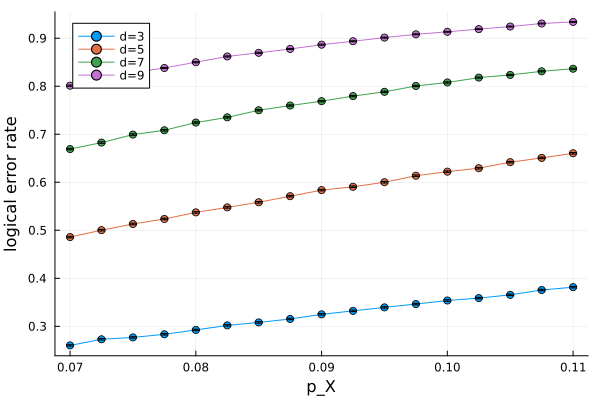

In [34]:
linecolors = get_color_palette(:auto, plot_color(:white))

g = plot()
for (ind_d, d) in enumerate(drange)
    p_success = [row[ind_d] for row in p_success_grid]
    p_fail = 1 .- p_success
    yerr = sqrt.(p_fail .* (1 .- p_fail) ./ num_total_samples)

    plot!(
        prange,
        p_fail;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
        yerr=yerr,
    )
end

plot!(
    xlabel="p_X",
    ylabel="logical error rate",
    # size=(900, 400),
)

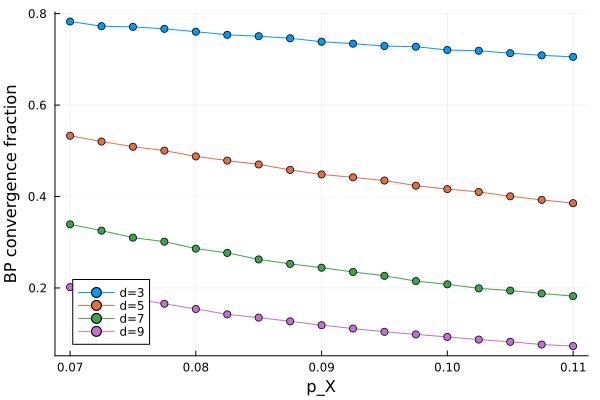

In [35]:
g2 = plot()
for (ind_d, d) in enumerate(drange)
    p_conv = [row[ind_d] for row in p_converged_grid]
    plot!(
        prange,
        p_conv;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="BP convergence fraction",
    # size=(900, 400),
)

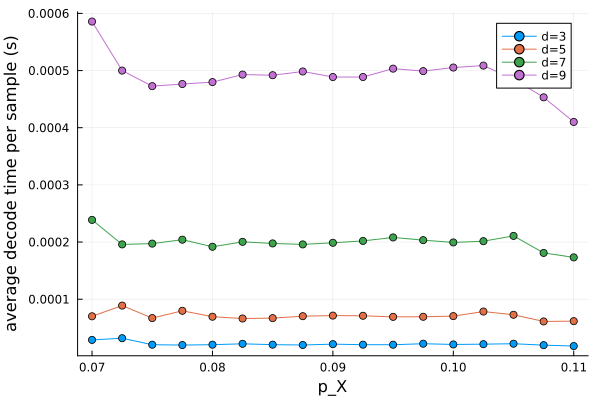

In [36]:
g3 = plot()
for (ind_d, d) in enumerate(drange)
    tavg = [row[ind_d] for row in t_grid]
    plot!(
        prange,
        tavg;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="average decode time per sample (s)",
    # size=(900, 400),
)

# Benchmark relay-bp

In [37]:
@everywhere function run_surface_xnoise_batch_relay_bp(
    HX::AbstractMatrix{<:Integer},
    HZ::AbstractMatrix{<:Integer},
    p::Float64,
    num_samples::Int;
)
    n = size(HZ, 2)

    num_success = 0
    num_converged = 0
    decode_time = 0.0

    for _ in 1:num_samples
        x_error = Int64.(rand(n) .< p)
        sx = mod.(HZ * x_error, 2)

        local result
        decode_time += @elapsed result = relay_bp_decode(HZ, sx, p)

        residual = mod.(x_error .+ result.error, 2)
        if is_in_rowspace_mod2(residual, HX)
            num_success += 1
        end

        if result.converged
            num_converged += 1
        end
    end

    return num_success, num_converged, decode_time
end

In [38]:
type_lattice = "surface_relay_bp_xnoise"
logfile = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples)_log.txt"
open(logfile, "w") do file
end

@time results = pmap(1:num_cores) do _
    p_success_list = Dict(pd_range .=> 0.0)
    p_converged_list = Dict(pd_range .=> 0.0)
    t_list = Dict(pd_range .=> 0.0)

    HXs = Dict{Int, Matrix{Int64}}()
    HZs = Dict{Int, Matrix{Int64}}()

    for d in drange
        HXs[d] = stabilizer_dict_to_check_matrix(surface_code_X_stabilizers(d), d^2)
        HZs[d] = stabilizer_dict_to_check_matrix(surface_code_Z_stabilizers(d), d^2)
    end

    for (ind_pd, (p, d)) in enumerate(pd_range)
        HX = HXs[d]
        HZ = HZs[d]

        walltime = @elapsed begin
            num_success, num_converged, decode_time = run_surface_xnoise_batch_relay_bp(
                HX, HZ, p, num_samples_each_core
            )

            p_success_list[(p, d)] += num_success
            p_converged_list[(p, d)] += num_converged
            t_list[(p, d)] += decode_time
        end

        if myid() == 2
            println("$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))")
            open(logfile, "a") do file
                write(file, "$(ind_pd)/$(length(pd_range)), d=$(d), p=$(p), walltime=$(walltime), $(string(now()))\n")
            end
        end
    end

    return p_success_list, p_converged_list, t_list
end

p_success_list = merge(+, [res[1] for res in results]...)
p_converged_list = merge(+, [res[2] for res in results]...)
t_list = merge(+, [res[3] for res in results]...)

for key in keys(p_success_list)
    p_success_list[key] /= num_total_samples
    p_converged_list[key] /= num_total_samples
    t_list[key] /= num_total_samples
end

fn = "$(type_lattice)_$(dmin)_$(dmax)_$(prange[1])_$(prange[end])_$(num_total_samples).jld2"
jldsave(
    fn;
    prange=prange,
    drange=drange,
    num_samples=num_total_samples,
    p_success_list=p_success_list,
    p_converged_list=p_converged_list,
    t_list=t_list,
)

      From worker 2:	1/68, d=3, p=0.07, walltime=1.026819625, 2026-03-29T14:25:42.075
      From worker 2:	2/68, d=5, p=0.07, walltime=2.74637325, 2026-03-29T14:25:44.845
      From worker 2:	3/68, d=7, p=0.07, walltime=7.525698292, 2026-03-29T14:25:52.372
      From worker 2:	4/68, d=9, p=0.07, walltime=16.695216, 2026-03-29T14:26:09.069
      From worker 2:	5/68, d=3, p=0.0725, walltime=0.655653875, 2026-03-29T14:26:09.729
      From worker 2:	6/68, d=5, p=0.0725, walltime=2.471871834, 2026-03-29T14:26:12.202
      From worker 2:	7/68, d=7, p=0.0725, walltime=7.16120275, 2026-03-29T14:26:19.368
      From worker 2:	8/68, d=9, p=0.0725, walltime=16.850466833, 2026-03-29T14:26:36.220
      From worker 2:	9/68, d=3, p=0.075, walltime=0.616707334, 2026-03-29T14:26:36.846
      From worker 2:	10/68, d=5, p=0.075, walltime=2.46931425, 2026-03-29T14:26:39.316
      From worker 2:	11/68, d=7, p=0.075, walltime=8.152899292, 2026-03-29T14:26:47.472
      From worker 2:	12/68, d=9, p=0.075, wal

In [39]:
p_success_grid = get_grid_from_dict(p_success_list, drange, prange)
p_converged_grid = get_grid_from_dict(p_converged_list, drange, prange)
t_grid = get_grid_from_dict(t_list, drange, prange)

17-element Vector{Vector{Float64}}:
 [5.308732750999996e-5, 0.00014094363642999977, 0.0003190366773900003, 0.0006772010761099995]
 [3.8089928499999835e-5, 0.0001288703092400001, 0.00032013650100999987, 0.0006852872456100005]
 [3.691036668999984e-5, 0.00013756596563999996, 0.0003494996002200001, 0.0006889374670100015]
 [3.570544511999987e-5, 0.00013301306273000006, 0.00033207032852999944, 0.0006843526825299996]
 [4.464689236999996e-5, 0.00015698191151000004, 0.00034492528783999906, 0.0006918579095999997]
 [3.6877348239999824e-5, 0.0001371362315200001, 0.00035282282027000034, 0.0007007227128500006]
 [3.834678092999986e-5, 0.00013923840666000008, 0.00036067157960000034, 0.0007050919706600003]
 [3.964252359999988e-5, 0.00014128410156000014, 0.00036180407566000004, 0.000738742900080002]
 [4.1459516559999837e-5, 0.00014488390666, 0.0003584629229499994, 0.0028232485585399955]
 [3.801286565999985e-5, 0.003533368769459996, 0.00046660226752000055, 0.007071200619059979]
 [0.0034665083096099766, 0

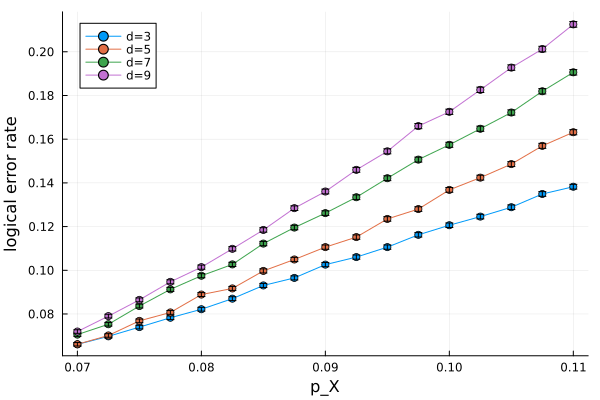

In [40]:
linecolors = get_color_palette(:auto, plot_color(:white))

g = plot()
for (ind_d, d) in enumerate(drange)
    p_success = [row[ind_d] for row in p_success_grid]
    p_fail = 1 .- p_success
    yerr = sqrt.(p_fail .* (1 .- p_fail) ./ num_total_samples)

    plot!(
        prange,
        p_fail;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
        yerr=yerr,
    )
end

plot!(
    xlabel="p_X",
    ylabel="logical error rate",
    # size=(900, 400),
)

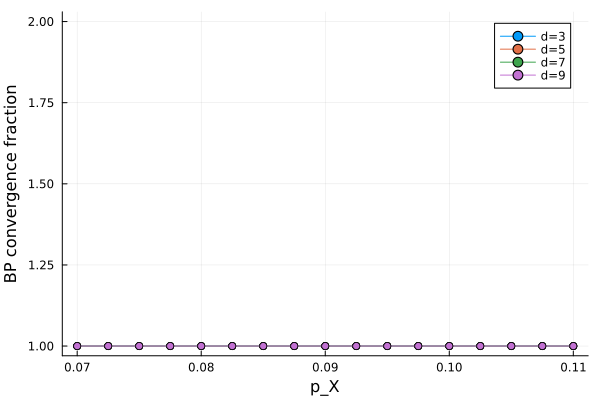

In [41]:
g2 = plot()
for (ind_d, d) in enumerate(drange)
    p_conv = [row[ind_d] for row in p_converged_grid]
    plot!(
        prange,
        p_conv;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="BP convergence fraction",
    # size=(900, 400),
)

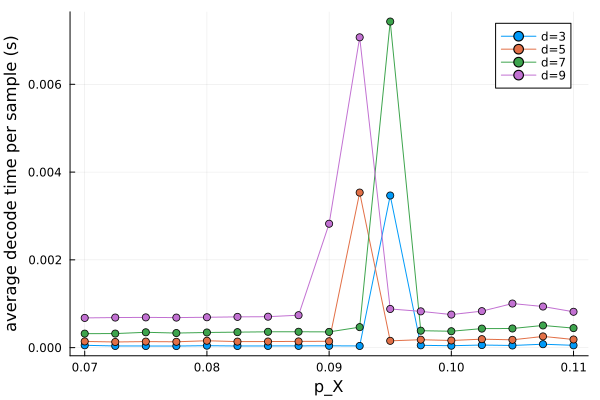

In [42]:
g3 = plot()
for (ind_d, d) in enumerate(drange)
    tavg = [row[ind_d] for row in t_grid]
    plot!(
        prange,
        tavg;
        label="d=$d",
        marker=:circle,
        color=linecolors[ind_d],
    )
end

plot!(
    xlabel="p_X",
    ylabel="average decode time per sample (s)",
    # size=(900, 400),
)